In [29]:
import os

import numpy as np
import pandas as pd
from cohere import ClientV2
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances


In [5]:
### Load the metadata
df = pd.read_csv('arxiv_papers_20260328.csv')

### Load the Cohere embeddings
embeddings = np.load('embeddings_cohere.npy')


In [18]:
df.iloc[300]["abstract"]

'Translating natural language to SQL for data retrieval has become more accessible thanks to code generation LLMs. But how hard is it to generate SQL code? While databases can become unbounded in complexity, the complexity of queries is bounded by real life utility and human needs. With a sample of 376 databases, we show that SQL queries, as translations of natural language questions are finite in practical complexity. There is no clear monotonic relationship between increases in database table count and increases in complexity of SQL queries. In their template forms, SQL queries follow a Power Law-like distribution of frequency where 70% of our tested queries can be covered with just 13% of all template types, indicating that the high majority of SQL queries are predictable. This suggests that while LLMs for code generation can be useful, in the domain of database access, they may be operating in a narrow, highly formulaic space where templates could be safer, cheaper, and auditable.'

In [6]:
print(f"Loaded {len(df)} papers")

print(f"Loaded embeddings with shape: {embeddings.shape}")
print(f"Each paper is represented by a {embeddings.shape[1]}-dimensional vector")


### Verify the data loaded correctly
print(f"\nFirst paper title: {df['title'].iloc[0]}")
print(f"First embedding (first 5 values): {embeddings[0][:5]}")

Loaded 500 papers
Loaded embeddings with shape: (500, 1536)
Each paper is represented by a 1536-dimensional vector

First paper title: Drive My Way: Preference Alignment of Vision-Language-Action Model for Personalized Driving
First embedding (first 5 values): [-0.0137771   0.0080296  -0.02214478 -0.00177496 -0.01884842]


In [ ]:
"""
To calculate the distance between embedding vectors, we need a distance metric.
There are three commonly used metrics for measuring similarity between embeddings:

- Euclidean Distance: Measures the straight-line distance between vectors in space.
  A shorter distance means higher similarity. You can think of it as measuring the
  physical distance between two points.

- Dot Product: Multiplies corresponding elements and sums them up.
  Considers both direction and magnitude of the vectors.
  Works well when embeddings are normalized to unit length.

- Cosine Similarity: Measures the angle between vectors.
  If two vectors point in the same direction, they're similar, regardless of their length.
  This is the most common metric for text embeddings.
"""

In [7]:
def euclidean_distance_manual(vec1, vec2):
    """
    Calculate Euclidean distance between two vectors.

    Parameters:
    -----------
    vec1, vec2 : numpy arrays
        The vectors to compare

    Returns:
    --------
    float
        Euclidean distance (lower means more similar)
    """
    # np.linalg.norm computes the square root of sum of squared differences
    # This implements the Euclidean distance formula directly
    return np.linalg.norm(vec1 - vec2)

In [ ]:
### test by comparing two similar papers
paper_idx_1 = 492  # Android compliance detection paper
paper_idx_2 = 493  # GDPR benchmarking paper

distance = euclidean_distance_manual(embeddings[paper_idx_1], embeddings[paper_idx_2])

In [9]:
embeddings[paper_idx_1].reshape(1, -1)

array([[ 0.05312345, -0.00152606,  0.00944509, ..., -0.00451632,
         0.05180361, -0.03068621]])

In [10]:
# calculating distance to all papers, we can use scikit-learn
### Calculate distance from one paper to all others
query_embedding = embeddings[paper_idx_1].reshape(1, -1)
all_distances = euclidean_distances(query_embedding, embeddings)

### Get top 10 (lowest distances = most similar)
top_indices = np.argsort(all_distances[0])[1:11]

print(f"Query paper: {df['title'].iloc[paper_idx_1]}\n")
print("Top 10 papers by Euclidean distance (lowest = most similar):")
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. [{all_distances[0][idx]:.4f}] {df['title'].iloc[idx][:50]}...")

Query paper: LLM-Powered Workflow Optimization for Multidisciplinary Software Development: An Automotive Industry Case Study

Top 10 papers by Euclidean distance (lowest = most similar):
1. [1.0626] Sketch2Simulation: Automating Flowsheet Generation...
2. [1.0801] The Evolution of Tool Use in LLM Agents: From Sing...
3. [1.0873] DomAgent: Leveraging Knowledge Graphs and Case-Bas...
4. [1.0888] Factors Influencing the Quality of AI-Generated Co...
5. [1.0910] MobileDev-Bench: A Comprehensive Benchmark for Eva...
6. [1.0913] MobileDev-Bench: A Comprehensive Benchmark for Eva...
7. [1.0921] Emergent Formal Verification: How an Autonomous AI...
8. [1.0957] Early Discoveries of Algorithmist I: Promise of Pr...
9. [1.0969] APISENSOR: Robust Discovery of Web API from Runtim...
10. [1.0985] The Specification Gap: Coordination Failure Under ...


In [11]:
def dot_product_similarity_manual(vec1, vec2):
    """
    Calculate dot product between two vectors.

    Parameters:
    -----------
    vec1, vec2 : numpy arrays
        The vectors to compare

    Returns:
    --------
    float
        Dot product score (higher means more similar)
    """
    # np.dot multiplies corresponding elements and sums them
    # This directly implements the dot product formula
    return np.dot(vec1, vec2)

In [12]:
### Compare the same papers using dot product
similarity_dot = dot_product_similarity_manual(
    embeddings[paper_idx_1], embeddings[paper_idx_2]
)

print(f"Comparing the same two papers:")
print(f"  Dot product: {similarity_dot:.4f}")

Comparing the same two papers:
  Dot product: 0.4089


In [13]:
### Efficient dot product for one query against all papers
query_embedding = embeddings[paper_idx_1]
all_dot_products = np.dot(embeddings, query_embedding)

### Get top 10 results
top_indices = np.argsort(all_dot_products)[::-1][1:11]

print(f"Query paper: {df['title'].iloc[paper_idx_1]}\n")
print("Top 10 papers by dot product similarity:")
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. [{all_dot_products[idx]:.4f}] {df['title'].iloc[idx][:50]}...")

Query paper: LLM-Powered Workflow Optimization for Multidisciplinary Software Development: An Automotive Industry Case Study

Top 10 papers by dot product similarity:
1. [0.4355] Sketch2Simulation: Automating Flowsheet Generation...
2. [0.4167] The Evolution of Tool Use in LLM Agents: From Sing...
3. [0.4089] DomAgent: Leveraging Knowledge Graphs and Case-Bas...
4. [0.4072] Factors Influencing the Quality of AI-Generated Co...
5. [0.4049] MobileDev-Bench: A Comprehensive Benchmark for Eva...
6. [0.4045] MobileDev-Bench: A Comprehensive Benchmark for Eva...
7. [0.4037] Emergent Formal Verification: How an Autonomous AI...
8. [0.3997] Early Discoveries of Algorithmist I: Promise of Pr...
9. [0.3984] APISENSOR: Robust Discovery of Web API from Runtim...
10. [0.3967] The Specification Gap: Coordination Failure Under ...


In [14]:
def cosine_similarity_manual(vec1, vec2):
    """
    Calculate cosine similarity between two vectors.

    Parameters:
    -----------
    vec1, vec2 : numpy arrays
        The vectors to compare

    Returns:
    --------
    float
        Cosine similarity score between -1 and 1
    """
    # Calculate dot product (numerator)
    dot_product = np.dot(vec1, vec2)

    # Calculate magnitudes using np.linalg.norm (denominator)
    # np.linalg.norm computes sqrt(sum of squared values)
    magnitude1 = np.linalg.norm(vec1)
    magnitude2 = np.linalg.norm(vec2)

    # Divide dot product by product of magnitudes
    similarity = dot_product / (magnitude1 * magnitude2)

    return similarity

In [15]:
### Test with our software engineering papers
similarity = cosine_similarity_manual(embeddings[paper_idx_1],
                                     embeddings[paper_idx_2])

print(f"Comparing two papers:")
print(f"Paper 1: {df['title'].iloc[paper_idx_1][:50]}...")
print(f"Paper 2: {df['title'].iloc[paper_idx_2][:50]}...")
print(f"\nCosine similarity: {similarity:.4f}")

Comparing two papers:
Paper 1: LLM-Powered Workflow Optimization for Multidiscipl...
Paper 2: DomAgent: Leveraging Knowledge Graphs and Case-Bas...

Cosine similarity: 0.4089


In [ ]:
"""
The cosine similarity (0.6446) is identical to the dot product we calculated earlier.
This isn't a coincidence. Cohere's embeddings are normalized to unit length,
which means the dot product and cosine similarity are mathematically equivalent for these vectors.
When embeddings are normalized, the denominator in the cosine formula
(the product of the vector magnitudes) always equals 1, leaving just the dot product.
This is why many vector databases prefer dot product for normalized embeddings.
It's computationally cheaper and produces identical results to cosine.
"""

In [19]:
paper_idx_3 = 300 # Translating natural language to SQL for data retrieval

### Compare a software engineering paper to a database paper
similarity_related = cosine_similarity_manual(embeddings[paper_idx_1],
                                             embeddings[paper_idx_2])
similarity_unrelated = cosine_similarity_manual(embeddings[paper_idx_1],
                                               embeddings[paper_idx_3])

print(f"Software Engineering paper 1 vs Software Engineering paper 2:")
print(f"  Similarity: {similarity_related:.4f}")
print(f"\nSoftware Engineering paper vs Database paper:")
print(f"  Similarity: {similarity_unrelated:.4f}")
print(f"\nThe SE papers are {similarity_related/similarity_unrelated:.2f}x more similar")

Software Engineering paper 1 vs Software Engineering paper 2:
  Similarity: 0.4089

Software Engineering paper vs Database paper:
  Similarity: 0.2417

The SE papers are 1.69x more similar


In [22]:

### Calculate similarity between one paper and all other papers
query_embedding = embeddings[paper_idx_1].reshape(1, -1)
all_similarities = cosine_similarity(query_embedding, embeddings)

### Get the top 10 most similar papers (excluding the query itself)
top_indices = np.argsort(all_similarities[0])[::-1][1:11]

print(f"Query paper: {df['title'].iloc[paper_idx_1]}\n")
print("Top 10 most similar papers:")
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. [{all_similarities[0][idx]:.4f}] {df['title'].iloc[idx][:50]}...")

Query paper: LLM-Powered Workflow Optimization for Multidisciplinary Software Development: An Automotive Industry Case Study

Top 10 most similar papers:
1. [0.4355] Sketch2Simulation: Automating Flowsheet Generation...
2. [0.4167] The Evolution of Tool Use in LLM Agents: From Sing...
3. [0.4089] DomAgent: Leveraging Knowledge Graphs and Case-Bas...
4. [0.4072] Factors Influencing the Quality of AI-Generated Co...
5. [0.4049] MobileDev-Bench: A Comprehensive Benchmark for Eva...
6. [0.4045] MobileDev-Bench: A Comprehensive Benchmark for Eva...
7. [0.4037] Emergent Formal Verification: How an Autonomous AI...
8. [0.3997] Early Discoveries of Algorithmist I: Promise of Pr...
9. [0.3984] APISENSOR: Robust Discovery of Web API from Runtim...
10. [0.3967] The Specification Gap: Coordination Failure Under ...


In [23]:
### Compare rankings from all three metrics for a single query
query_embedding = embeddings[paper_idx_1].reshape(1, -1)

### Calculate similarities/distances
cosine_scores = cosine_similarity(query_embedding, embeddings)[0]
dot_scores = np.dot(embeddings, embeddings[paper_idx_1])
euclidean_scores = euclidean_distances(query_embedding, embeddings)[0]

### Get top 10 indices for each metric
top_cosine = set(np.argsort(cosine_scores)[::-1][1:11])
top_dot = set(np.argsort(dot_scores)[::-1][1:11])
top_euclidean = set(np.argsort(euclidean_scores)[1:11])

### Calculate overlap
cosine_dot_overlap = len(top_cosine & top_dot)
cosine_euclidean_overlap = len(top_cosine & top_euclidean)
all_three_overlap = len(top_cosine & top_dot & top_euclidean)

print(f"Top 10 papers overlap between metrics:")
print(f"  Cosine & Dot Product: {cosine_dot_overlap}/10 papers match")
print(f"  Cosine & Euclidean: {cosine_euclidean_overlap}/10 papers match")
print(f"  All three metrics: {all_three_overlap}/10 papers match")

Top 10 papers overlap between metrics:
  Cosine & Dot Product: 10/10 papers match
  Cosine & Euclidean: 10/10 papers match
  All three metrics: 10/10 papers match


In [25]:
### Load Cohere API key
load_dotenv()
cohere_api_key = os.getenv('COHERE_API_KEY')
co = ClientV2(api_key=cohere_api_key)

In [26]:
def semantic_search(query, embeddings, df, top_k=5, metric='cosine'):
    """
    Search for papers semantically similar to a query.

    Parameters:
    -----------
    query : str
        Natural language search query
    embeddings : numpy array
        Pre-computed embeddings for all papers
    df : pandas DataFrame
        DataFrame containing paper metadata
    top_k : int
        Number of results to return
    metric : str
        Similarity metric to use ('cosine', 'dot', or 'euclidean')

    Returns:
    --------
    pandas DataFrame
        Top results with similarity scores
    """
    # Generate embedding for the query
    response = co.embed(
        texts=[query],
        model='embed-v4.0',
        input_type='search_query',
        embedding_types=['float']
    )
    query_embedding = np.array(response.embeddings.float_[0]).reshape(1, -1)

    # Calculate similarities based on chosen metric
    if metric == 'cosine':
        scores = cosine_similarity(query_embedding, embeddings)[0]
        top_indices = np.argsort(scores)[::-1][:top_k]
    elif metric == 'dot':
        scores = np.dot(embeddings, query_embedding.flatten())
        top_indices = np.argsort(scores)[::-1][:top_k]
    elif metric == 'euclidean':
        scores = euclidean_distances(query_embedding, embeddings)[0]
        top_indices = np.argsort(scores)[:top_k]
        scores = 1 / (1 + scores)
    else:
        raise ValueError(f"Unknown metric: {metric}")

    # Create results DataFrame
    results = df.iloc[top_indices].copy()
    results['similarity_score'] = scores[top_indices]
    results = results[['title', 'category', 'similarity_score', 'abstract']]

    return results

In [27]:


### Test the search function
query = "query optimization algorithms"
results = semantic_search(query, embeddings, df, top_k=5)

separator = "=" * 80
print(f"Query: '{query}'\n")
print(f"Top 5 most relevant papers:\n{separator}")
for idx, row in results.iterrows():
    print(f"\n{row['title']}")
    print(f"Category: {row['category']} | Similarity: {row['similarity_score']:.4f}")
    print(f"Abstract: {row['abstract'][:150]}...")

Query: 'query optimization algorithms'

Top 5 most relevant papers:

ListK: Semantic ORDER BY and LIMIT K with Listwise Prompting
Category: cs.DB | Similarity: 0.4055
Abstract: Semantic operators abstract large language model (LLM) calls in SQL clauses. It is gaining traction as an easy method to analyze semi-structured, unst...

Towards Output-Optimal Uniform Sampling and Approximate Counting for Join-Project Queries
Category: cs.DB | Similarity: 0.4012
Abstract: Uniform sampling and approximate counting are fundamental primitives for modern database applications, ranging from query optimization to approximate ...

MICRO: A Lightweight Middleware for Optimizing Cross-store Cross-model Graph-Relation Joins [Technical Report]
Category: cs.DB | Similarity: 0.3728
Abstract: Modern data applications increasingly involve heterogeneous data managed in different models and stored across disparate database engines, often deplo...

SIMD-PAC-DB: Pretty Performant PAC Privacy
Category: cs.DB | Si

In [28]:
### Test multiple queries
test_queries = [
    "language model pretraining",
    "reinforcement learning algorithms",
    "code quality analysis"
]

for query in test_queries:
    print(f"\nQuery: '{query}'\n{separator}")
    results = semantic_search(query, embeddings, df, top_k=3)

    for idx, row in results.iterrows():
        print(f"  [{row['similarity_score']:.4f}] {row['title'][:50]}...")
        print(f"           Category: {row['category']}")


Query: 'language model pretraining'
  [0.4221] Synthetic Rewriting as a Quality Multiplier: Evide...
           Category: cs.CL
  [0.4104] GoldiCLIP: The Goldilocks Approach for Balancing E...
           Category: cs.LG
  [0.3654] Demystifying When Pruning Works via Representation...
           Category: cs.CL

Query: 'reinforcement learning algorithms'
  [0.3571] Maximum Entropy Behavior Exploration for Sim2Real ...
           Category: cs.LG
  [0.3475] Reinforcement learning for quantum processes with ...
           Category: cs.LG
  [0.3204] Fault-Tolerant Design and Multi-Objective Model Ch...
           Category: cs.SE

Query: 'code quality analysis'
  [0.4384] A Study of Scientific Computational Notebook Quali...
           Category: cs.SE
  [0.3863] SlopCodeBench: Benchmarking How Coding Agents Degr...
           Category: cs.CL
  [0.3863] SlopCodeBench: Benchmarking How Coding Agents Degr...
           Category: cs.SE


In [30]:
def visualize_search_results(query, embeddings, df, top_k=10):
    """
    Visualize search results in 2D embedding space.
    """
    # Get search results
    response = co.embed(
        texts=[query],
        model='embed-v4.0',
        input_type='search_query',
        embedding_types=['float']
    )
    query_embedding = np.array(response.embeddings.float_[0])

    # Calculate similarities
    similarities = cosine_similarity(query_embedding.reshape(1, -1), embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # Combine query embedding with all paper embeddings for PCA
    all_embeddings_with_query = np.vstack([query_embedding, embeddings])

    # Reduce to 2D
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(all_embeddings_with_query)

    # Split back into query and papers
    query_2d = embeddings_2d[0]
    papers_2d = embeddings_2d[1:]

    # Create visualization
    plt.figure(figsize=(8, 6))

    # Define colors for categories
    colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A']
    category_codes = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE']
    category_names = ['Machine Learning', 'Computer Vision', 'Comp. Linguistics',
                     'Databases', 'Software Eng.']

    # Plot all papers with subtle colors
    for i, (cat_code, cat_name, color) in enumerate(zip(category_codes,
                                                         category_names, colors)):
        mask = df['category'] == cat_code
        cat_embeddings = papers_2d[mask]
        plt.scatter(cat_embeddings[:, 0], cat_embeddings[:, 1],
                   c=color, label=cat_name, s=30, alpha=0.3, edgecolors='none')

    # Highlight top results
    top_embeddings = papers_2d[top_indices]
    plt.scatter(top_embeddings[:, 0], top_embeddings[:, 1],
               c='black', s=150, alpha=0.6, edgecolors='yellow', linewidth=2,
               marker='o', label=f'Top {top_k} Results', zorder=5)

    # Plot query point
    plt.scatter(query_2d[0], query_2d[1],
               c='red', s=400, alpha=0.9, edgecolors='black', linewidth=2,
               marker='*', label='Query', zorder=10)

    # Draw lines from query to top results
    for idx in top_indices:
        plt.plot([query_2d[0], papers_2d[idx, 0]],
                [query_2d[1], papers_2d[idx, 1]],
                'k--', alpha=0.2, linewidth=1, zorder=1)

    plt.xlabel('First Principal Component', fontsize=12)
    plt.ylabel('Second Principal Component', fontsize=12)
    plt.title(f'Search Results for: "{query}"\n' +
             '(Query shown as red star, top results highlighted)',
             fontsize=14, fontweight='bold', pad=20)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print the top results
    print(f"\nTop {top_k} results for query: '{query}'\n{separator}")
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank}. [{similarities[idx]:.4f}] {df['title'].iloc[idx][:50]}...")
        print(f"Category: {df['category'].iloc[idx]}")

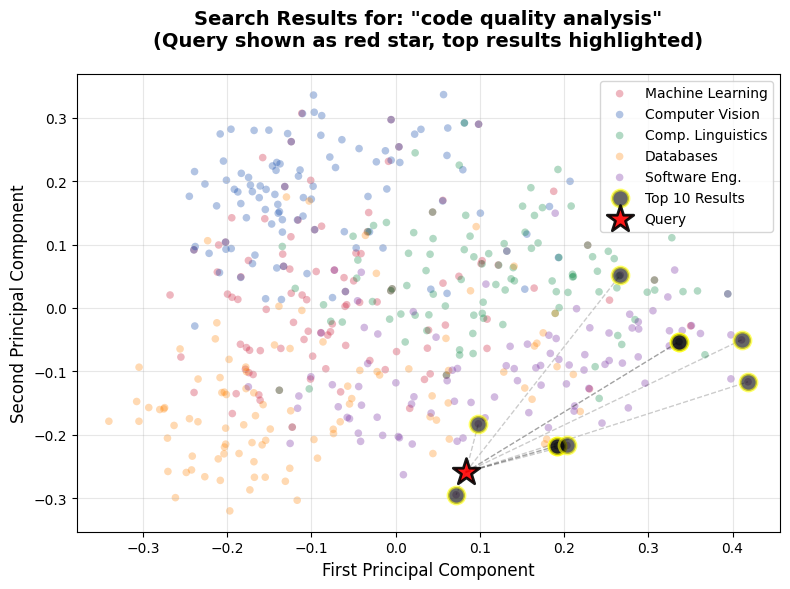


Top 10 results for query: 'code quality analysis'
1. [0.4388] A Study of Scientific Computational Notebook Quali...
Category: cs.SE
2. [0.3860] SlopCodeBench: Benchmarking How Coding Agents Degr...
Category: cs.CL
3. [0.3860] SlopCodeBench: Benchmarking How Coding Agents Degr...
Category: cs.SE
4. [0.3730] Comparing Developer and LLM Biases in Code Evaluat...
Category: cs.SE
5. [0.3730] Comparing Developer and LLM Biases in Code Evaluat...
Category: cs.CL
6. [0.3721] LLMLOOP: Improving LLM-Generated Code and Tests th...
Category: cs.SE
7. [0.3673] Which Alert Removals are Beneficial?...
Category: cs.SE
8. [0.3535] ConceptCoder: Improve Code Reasoning via Concept L...
Category: cs.SE
9. [0.3509] Factors Influencing the Quality of AI-Generated Co...
Category: cs.SE
10. [0.3503] Code Review Agent Benchmark...
Category: cs.SE


In [32]:

### Visualize search results for a query
# query = "language model pretraining"
query = "code quality analysis"
visualize_search_results(query, embeddings, df, top_k=10)

In [ ]:
"""
To know if the  search system is working well especially in production systems,
one would use quantitative metrics like Precision@K, Recall@K, or Mean Average Precision (MAP)

Below, qualitative evaluation will be used i.e. similarity score interpretation.
It depends heavily on a dataset's characteristics.

Below are general heuristics, but they require adjustment based on your specific data;

*** For broad, multi-domain datasets (like now studied with 5 distinct categories):
- 0.40+: Highly relevant
- 0.30-0.40: Very relevant
- 0.25-0.30: Moderately relevant
- Below 0.25: Questionable relevance

*** For narrow, specialized datasets (single domain): - where my language specific
- 0.70+: Highly relevant
- 0.60-0.70: Very relevant
- 0.50-0.60: Moderately relevant
- Below 0.50: Questionable relevance
"""

"\nTo know if the  search system is working well especially in production systems,\none would use quantitative metrics like Precision@K, Recall@K, or Mean Average Precision (MAP)\n\nBelow, qualitative evaluation will be used i.e. similarity score interpretation.\nIt depends heavily on a dataset's characteristics.\n\nBelow are general heuristics, but they require adjustment based on your specific data;\n"

In [34]:
# a good search system should handle different types of queries gracefully. testing some edge cases;


### Test 1: Very specific technical query
print(f"Test 1: Highly Specific Query\n{separator}")
query = "graph neural networks for molecular property prediction"
results = semantic_search(query, embeddings, df, top_k=3)
print(f"Query: '{query}'\n")
for idx, row in results.iterrows():
    print(f"  [{row['similarity_score']:.4f}] {row['title'][:50]}...")

### Test 2: Broad general query
print(f"\n\nTest 2: Broad General Query\n{separator}")
query = "artificial intelligence"
results = semantic_search(query, embeddings, df, top_k=3)
print(f"Query: '{query}'\n")
for idx, row in results.iterrows():
    print(f"  [{row['similarity_score']:.4f}] {row['title'][:50]}...")

### Test 3: Query with common words
print(f"\n\nTest 3: Common Words Query\n{separator}")
query = "learning from data"
results = semantic_search(query, embeddings, df, top_k=3)
print(f"Query: '{query}'\n")
for idx, row in results.iterrows():
    print(f"  [{row['similarity_score']:.4f}] {row['title'][:50]}...")

Test 1: Highly Specific Query
Query: 'graph neural networks for molecular property prediction'

  [0.3842] DeePAW: A universal machine learning model for orb...
  [0.3611] UNIC: Neural Garment Deformation Field for Real-ti...
  [0.3512] Enabling ab initio geometry optimization of strong...


Test 2: Broad General Query
Query: 'artificial intelligence'

  [0.3379] DeePAW: A universal machine learning model for orb...
  [0.3260] 100x Cost & Latency Reduction: Performance Analysi...
  [0.3230] Can an LLM Detect Instances of Microservice Infras...


Test 3: Common Words Query
Query: 'learning from data'

  [0.3114] The Rules-and-Facts Model for Simultaneous General...
  [0.2823] How Class Ontology and Data Scale Affect Audio Tra...
  [0.2604] SportSkills: Physical Skill Learning from Sports I...


In [ ]:
"""
demonstrated is the power of semantic search over keyword matching.
A keyword search for "learning from data" would match almost everything,
but semantic search understands the intent and returns papers about data-driven learning and optimization
"""

In [ ]:
"""
a complete semantic search system has been presented.
The skills learned here transfer directly to any domain where there's a need to
find relevant documents based on meaning.

The pattern is always the same:

*** Collect documents (APIs, databases, file systems)

*** Generate embeddings (local models or API services)
*** Store embeddings efficiently (files or vector databases)
*** Implement similarity calculations (cosine, dot product, or Euclidean)
*** Build a search function that returns ranked results
*** Evaluate results to ensure quality

This exact workflow applies whether you're building:
- A research paper search engine (what we just built)
- A code search system for documentation
- A customer support knowledge base
- A product recommendation system
- A legal document retrieval system

The only difference is the data source. Everything else remains the same.
"""

In [ ]:
"""
Learnings;

- understand three distance metrics (Euclidean distance, dot product, cosine similarity) and when to use each one.
- can implement similarity calculations both manually (to understand the math) and efficiently (using scikit-learn).
- built a search function that converts queries to embeddings and returns ranked results.
- can visualize search results in embedding space to understand spatial relationships between queries and documents.
- can evaluate search quality qualitatively by examining results and similarity scores.
- understand how to optimize search systems for production with caching, approximate search, batching, vector databases, and document chunking.
"""

In [ ]:
"""
Experimentation


*** Test different query styles:
- Try very short queries ("neural nets") vs detailed queries ("applying deep neural networks to computer vision tasks")
- See how the system handles questions vs keywords
- Test queries that combine multiple topics

*** Explore the similarity threshold:
- Set a minimum similarity threshold (e.g., 0.30) and see how many results pass
- Test what happens with a very strict threshold (0.40+)
- Find the sweet spot for your use case

*** Analyze failure cases:
- Find queries where the results aren't great
- Understand why (too broad? too specific? wrong domain?)
- Think about how you'd improve the system

*** Compare categories:
- Search for "deep learning" and see which categories dominate results
- Try category-specific searches and verify papers match
- Look for interesting cross-category papers

*** Visualize different queries:
- Create visualizations for queries from different domains
- Observe how the query point moves in embedding space
- Notice which categories cluster near different types of queries


This experimentation sharpens intuition about how semantic search works
and prepares one to debug issues in ones own projects.
"""

In [ ]:
"""
Key Takeaways:

- Euclidean distance measures straight-line distance between vectors and is the most intuitive metric
- Dot product multiplies corresponding elements and is computationally efficient
- Cosine similarity measures the angle between vectors and is the standard for text embeddings
- For well-normalized embeddings, all three metrics typically produce similar rankings
- Similarity scores depend on dataset characteristics and should be interpreted relative to your specific data
- Multi-domain datasets naturally produce lower absolute scores than specialized single-topic datasets
- Visualizing search results in 2D embedding space helps understand clustering patterns, though exact rankings come from the full high-dimensional space
- The spatial proximity of embeddings directly corresponds to semantic similarity scores
- Production search systems benefit from query caching, approximate nearest neighbors, batch processing, vector databases, and document chunking
- The semantic search pattern (collect, embed, calculate similarity, rank) applies universally across domains
- Qualitative evaluation through manual inspection is crucial for understanding search quality
- Edge cases like very broad or very specific queries test the robustness of your search system
- These skills transfer directly to building search systems in any domain with any type of content
"""